# Demo 2: Understanding Attention with nanoGPT

This demo explores the attention mechanism in transformers using nanoGPT, a minimal implementation of GPT. We'll visualize how different attention heads learn to focus on different parts of the input text, helping us understand how transformers process and understand language.

## Key Concepts Covered
- Self-attention mechanism
- Multi-head attention
- Attention visualization
- Character-level processing

## Setup and Imports

First, we'll set up our environment and import necessary libraries. This includes:
1. Installing required packages
2. Setting up paths for nanoGPT
3. Importing the model components

In [ ]:
# Install required packages
%pip install -q torch matplotlib seaborn python-dotenv psutil

# Import libraries
import os
import torch
import numpy as np
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch.nn.functional as F

# Set up paths
notebook_dir = os.getcwd()
nanoGPT_dir = os.path.join(notebook_dir, "nanoGPT")

# Add nanoGPT to Python path
import sys

sys.path.append(nanoGPT_dir)

# Import model
from nanoGPT.model import GPTConfig, GPT


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Model Configuration

We'll use a small GPT model configuration suitable for educational purposes. The key parameters are:
- n_layer: Number of transformer layers
- n_head: Number of attention heads per layer
- n_embd: Size of the embedding dimension
- block_size: Maximum context length

In [ ]:
# Device setup
device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")

# Training hyperparameters
config = {
    "n_layer": 6,  # 6 layers
    "n_head": 6,  # 6 attention heads
    "n_embd": 384,  # 384 embedding size
    "dropout": 0.2,  # regularization
    "bias": False,
    "max_iters": 5000,  # training iterations
    "batch_size": 64,  # larger batch size for small model
    "gradient_accumulation_steps": 1,
    "block_size": 256,  # context of up to 256 previous characters
    "learning_rate": 1e-3,  # higher learning rate for small model
    "weight_decay": 1e-1,
    "beta1": 0.9,
    "beta2": 0.99,  # higher beta2 for small batches
    "grad_clip": 1.0,
}

# Initialize model
model_config = GPTConfig(
    block_size=config["block_size"],
    vocab_size=65,  # ASCII characters
    n_layer=config["n_layer"],
    n_head=config["n_head"],
    n_embd=config["n_embd"],
    dropout=config["dropout"],
    bias=config["bias"],
)

Using device: mps


## Model Training or Loading

We'll either load a pre-trained model or train a new one. This step:
1. Checks for existing model checkpoint
2. If found, loads the saved model
3. If not found, trains a new model

In [ ]:
# Check if we have a saved model
checkpoint_path = "02-model.pt"
if os.path.exists(checkpoint_path):
    print("Loading saved model...")
    checkpoint = torch.load(checkpoint_path)
    model = GPT(model_config)
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    model.eval()  # Set to evaluation mode
else:
    print("Training new model...")
    model = GPT(model_config)
    model.to(device)

    # Initialize optimizer
    optimizer = model.configure_optimizers(
        weight_decay=config["weight_decay"],
        learning_rate=config["learning_rate"],
        betas=(config["beta1"], config["beta2"]),
        device_type=device,
    )

    # Training loop
    print("Starting training...")
    model.train()
    last_time = time.time()

    # Pre-load data
    data_dir = os.path.join(nanoGPT_dir, "data", "shakespeare_char")
    data = np.memmap(
        os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r"
    )

    for iter_num in range(config["max_iters"]):
        # Get batch
        ix = torch.randint(
            len(data) - config["block_size"], (config["batch_size"],)
        )
        x = torch.stack([
            torch.from_numpy(
                (data[i : i + config["block_size"]]).astype(np.int64)
            )
            for i in ix
        ])
        y = torch.stack([
            torch.from_numpy(
                (data[i + 1 : i + 1 + config["block_size"]]).astype(np.int64)
            )
            for i in ix
        ])

        # Move to device
        x, y = x.to(device), y.to(device)

        # Forward pass
        logits, loss = model(x, y)

        # Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
        optimizer.step()

        # Logging
        if iter_num % 10 == 0:
            current_time = time.time()
            iter_time = current_time - last_time
            last_time = current_time
            progress = (iter_num + 1) / config["max_iters"] * 100
            print(
                f"iter {iter_num}: loss {loss.item():.4f} | time {iter_time:.2f}s | {progress:.1f}%"
            )

        # Save model on last iteration
        if iter_num == config["max_iters"] - 1:
            checkpoint = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "model_args": model_config.__dict__,
                "iter_num": iter_num,
                "best_val_loss": loss.item(),
            }
            torch.save(checkpoint, checkpoint_path)

Training new model...
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,096 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: False
Starting training...
iter 0: loss 4.2537 | time 0.62s | 0.0%
iter 10: loss 3.3210 | time 8.10s | 0.2%
iter 20: loss 3.2542 | time 8.09s | 0.4%
iter 30: loss 3.1613 | time 8.09s | 0.6%
iter 40: loss 2.9830 | time 8.12s | 0.8%
iter 50: loss 2.9126 | time 8.11s | 1.0%
iter 60: loss 2.7859 | time 8.15s | 1.2%
iter 70: loss 2.7379 | time 8.17s | 1.4%
iter 80: loss 2.6949 | time 8.20s | 1.6%
iter 90: loss 2.6550 | time 8.24s | 1.8%
iter 100: loss 2.6270 | time 8.25s | 2.0%
iter 110: loss 2.6226 | time 8.27s | 2.2%
iter 120: loss 2.5763 | time 8.31s | 2.4%
iter 130: loss 2.5567 | time 8.33s | 2.6%
iter 140: loss 2.5273 | time 8.37s | 2.8%
iter 150: loss 2.5143 | time 8.33s | 3.0%
iter 160: loss 2.5339 | time 8.36s | 3.2%
iter 170: loss 2.5284 | time 8.38s | 3.4%
iter 180: loss 2.5070 | time 8.37s 

## Load Saved Model

In [ ]:
# Load the saved model
checkpoint = torch.load(checkpoint_path)
model_config = GPTConfig(**checkpoint["model_args"])
model = GPT(model_config)
model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()  # Set to evaluation mode for visualization

number of parameters: 10.65M


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(65, 384)
    (wpe): Embedding(256, 384)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=False)
          (c_proj): Linear(in_features=384, out_features=384, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1536, out_features=384, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=384, out_features=65, bias=False)
)

## Attention Visualization Setup

Now we'll set up the functions to visualize attention patterns. This includes:
1. A function to extract attention weights
2. A function to visualize attention patterns
3. Helper functions for different visualization types

In [ ]:
def get_attention_patterns(model, x):
    """Extract attention patterns from the model without modifying its structure."""
    B, T = x.shape
    assert T <= model.config.block_size, (
        f"Cannot forward sequence of length {T}, block size is only {model.config.block_size}"
    )
    # Forward the GPT model
    tok_emb = model.transformer.wte(
        x
    )  # token embeddings of shape (b, t, n_embd)
    pos = torch.arange(0, T, dtype=torch.long, device=x.device).unsqueeze(
        0
    )  # shape (1, t)
    pos_emb = model.transformer.wpe(
        pos
    )  # position embeddings of shape (1, t, n_embd)
    x = model.transformer.drop(tok_emb + pos_emb)
    attention_weights = []
    # Forward through each block and capture attention
    for block in model.transformer.h:
        qkv = block.attn.c_attn(block.ln_1(x))
        q, k, v = qkv.split(model.config.n_embd, dim=2)
        B, T, C = x.shape
        k = k.view(B, T, block.attn.n_head, C // block.attn.n_head).transpose(
            1, 2
        )
        q = q.view(B, T, block.attn.n_head, C // block.attn.n_head).transpose(
            1, 2
        )
        v = v.view(B, T, block.attn.n_head, C // block.attn.n_head).transpose(
            1, 2
        )
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        if not block.attn.flash:
            att = att.masked_fill(
                block.attn.bias[:, :, :T, :T] == 0, float("-inf")
            )
        else:
            mask = torch.triu(
                torch.ones(T, T, device=x.device), diagonal=1
            ).bool()
            att = att.masked_fill(mask, float("-inf"))
        att = torch.nn.functional.softmax(att, dim=-1)
        attention_weights.append(att)
        x = x + block.attn(block.ln_1(x))
        x = x + block.mlp(block.ln_2(x))
    x = model.transformer.ln_f(x)
    logits = model.lm_head(x)
    return logits, attention_weights


def visualize_attention_subset(
    text, model, layer_idx=0, head_idx=0, max_tokens=20
):
    """Visualize a subset of the attention pattern for readability."""
    # Use only the first max_tokens characters
    chars = list(text)[:max_tokens]
    x = torch.tensor([ord(c) for c in chars], dtype=torch.long).unsqueeze(0)
    x = x.to(model.transformer.wte.weight.device)
    with torch.no_grad():
        logits, attention_weights = get_attention_patterns(model, x)
    attn = attention_weights[layer_idx][0, head_idx]
    plt.figure(figsize=(6, 5))
    plt.imshow(attn.cpu().numpy(), cmap="viridis")
    plt.xticks(range(len(chars)), chars, rotation=90)
    plt.yticks(range(len(chars)), chars)
    plt.title(
        f"Attention Pattern (Layer {layer_idx}, Head {head_idx}) [First {max_tokens} chars]"
    )
    plt.colorbar()
    plt.show()

## Visualizing Attention Patterns

Let's visualize attention patterns for different types of inputs. We'll start with:
1. A short input to see basic attention patterns
2. A complex input to see how attention handles longer sequences
3. Multiple attention heads to see different specializations

### Short Input Example

For a short input, we expect to see:
1. Strong diagonal patterns indicating local attention
2. Some attention to punctuation and special characters
3. Potential attention to repeated characters or patterns

This helps us understand how the model processes basic text structures.

Visualizing attention for short text: To be, or not to be


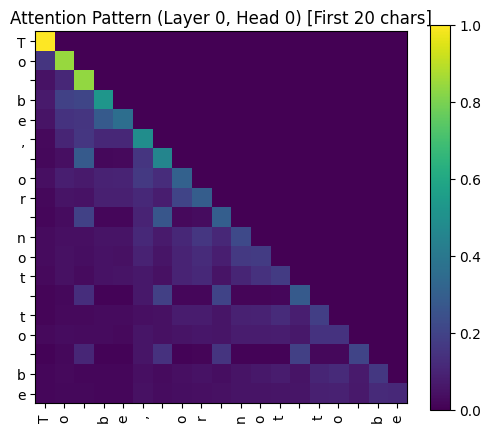

In [8]:
short_text = "To be, or not to be"
print("Visualizing attention for short text:", short_text)
visualize_attention_subset(short_text, model)

### Complex Input Example

With a longer, more complex input, we can observe:
1. How attention patterns evolve across different parts of the text
2. The emergence of longer-range dependencies
3. Specialized attention to different linguistic features
4. How the model handles repeated phrases and patterns

This demonstrates the model's ability to capture complex relationships in text.

Visualizing attention for complex text (first 40 chars): To be, or not to be, that is the questio...


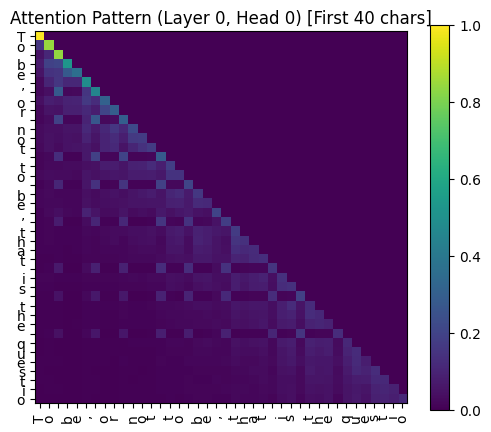

In [ ]:
complex_text = (
    "To be, or not to be, that is the question: "
    "Whether 'tis nobler in the mind to suffer "
    "The slings and arrows of outrageous fortune, "
    "Or to take arms against a sea of troubles "
    "And by opposing end them."
)
print(
    "Visualizing attention for complex text (first 40 chars):",
    complex_text[:40] + "...",
)
visualize_attention_subset(complex_text, model, max_tokens=40)

## Multi-Head Analysis

Now let's analyze how different attention heads specialize in different aspects of the text. We'll:
1. Visualize all heads in a layer
2. Compare attention patterns across heads
3. Understand how different heads capture different relationships

In [ ]:
def analyze_attention_heads_subset(text, model, layer_idx=0, max_tokens=20):
    """Analyze attention patterns across all heads in a layer for a subset of tokens."""
    chars = list(text)[:max_tokens]
    x = torch.tensor([ord(c) for c in chars], dtype=torch.long).unsqueeze(0)
    x = x.to(model.transformer.wte.weight.device)
    with torch.no_grad():
        logits, attention_weights = get_attention_patterns(model, x)
    n_heads = model.config.n_head
    n_cols = min(4, n_heads)
    n_rows = (n_heads + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(
        f"Attention Patterns Across Heads (Layer {layer_idx}) [First {max_tokens} chars]"
    )
    axes = axes.flatten() if n_heads > 1 else [axes]
    for i in range(n_heads):
        ax = axes[i]
        attn = attention_weights[layer_idx][0, i]
        im = ax.imshow(attn.cpu().numpy(), cmap="viridis")
        ax.set_xticks(range(len(chars)))
        ax.set_xticklabels(chars, rotation=90)
        ax.set_yticks(range(len(chars)))
        ax.set_yticklabels(chars)
        ax.set_title(f"Head {i}")
        plt.colorbar(im, ax=ax)
    for j in range(n_heads, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

### Multi-Head, Short Input

For a short input, we can observe:
1. How different heads specialize in different aspects of the text
2. The emergence of specialized attention patterns
3. The complementary nature of different heads

This helps us understand how multi-head attention enables the model to capture different types of relationships simultaneously.

Analyzing attention heads for short text: To be, or not to be


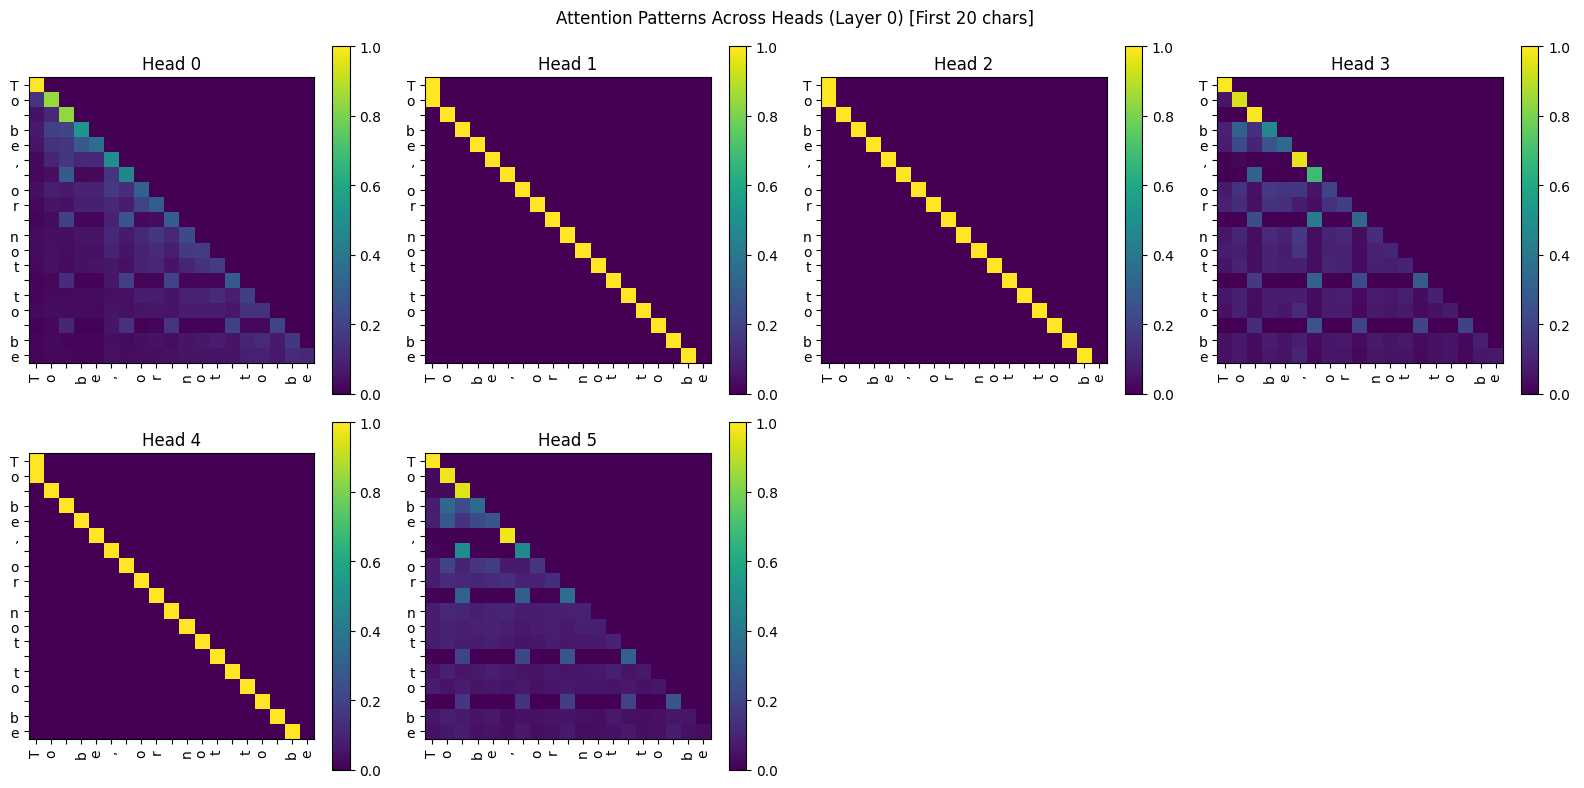

In [11]:
print("Analyzing attention heads for short text:", short_text)
analyze_attention_heads_subset(short_text, model)

### Multi-Head, Complex Input

With a complex input, we can see:
1. How different heads handle different aspects of the text
2. The emergence of specialized attention patterns for different linguistic features
3. The complementary nature of different heads in processing complex text

This demonstrates how multi-head attention enables the model to capture various types of relationships in complex text.

Analyzing attention heads for complex text (first 40 chars): To be, or not to be, that is the questio...


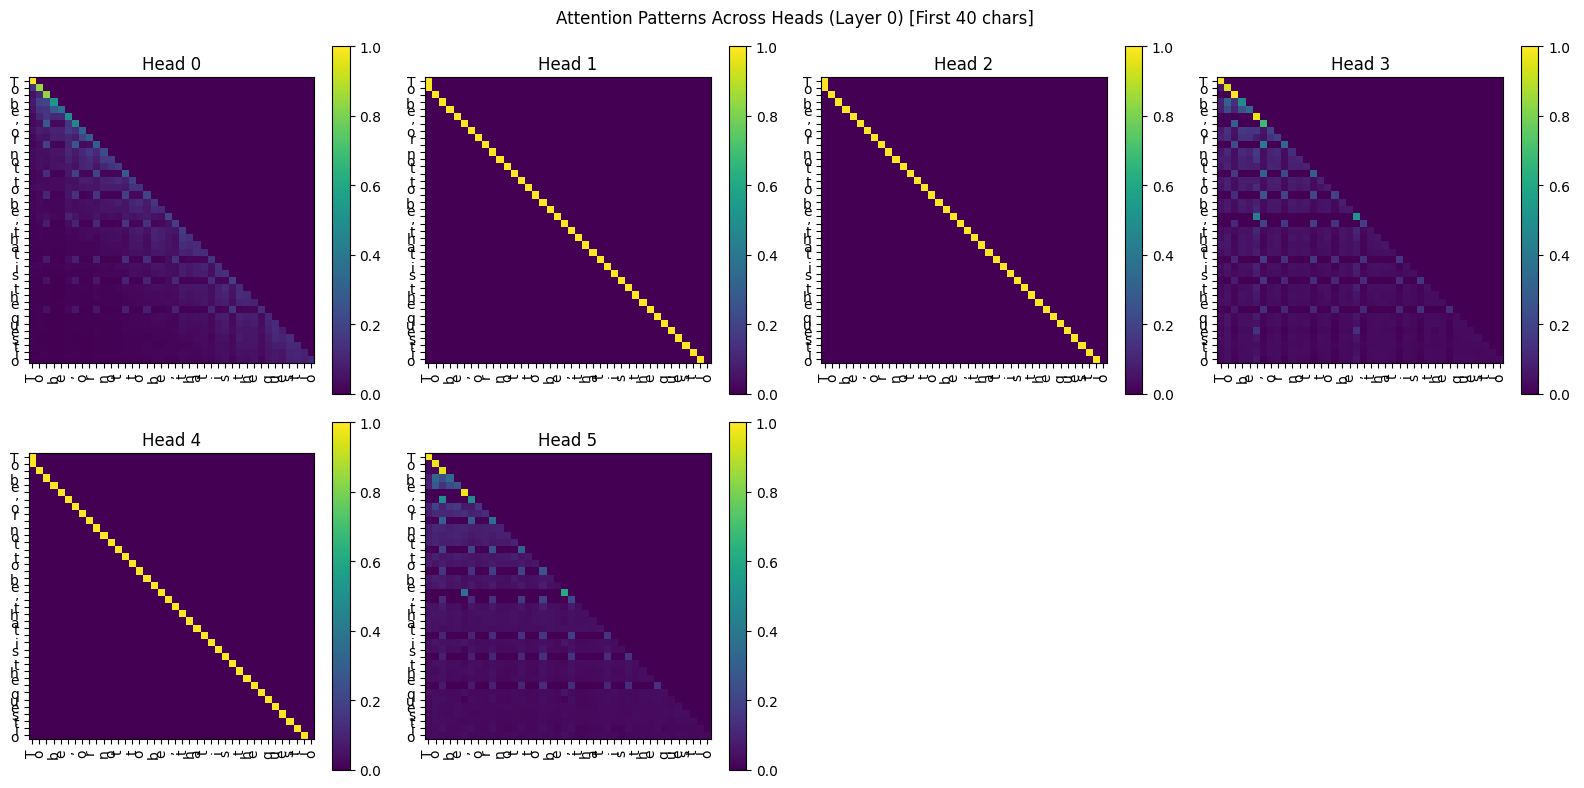

In [ ]:
print(
    "Analyzing attention heads for complex text (first 40 chars):",
    complex_text[:40] + "...",
)
analyze_attention_heads_subset(complex_text, model, max_tokens=40)

## Full Text Analysis

Finally, let's analyze the complete attention patterns across all heads for the full input text. This helps us understand:
1. How attention patterns evolve across the entire sequence
2. The role of different heads in processing different parts of the text
3. The emergence of specialized attention patterns for different linguistic features
4. How the model handles long-range dependencies

Analyzing full text attention patterns...


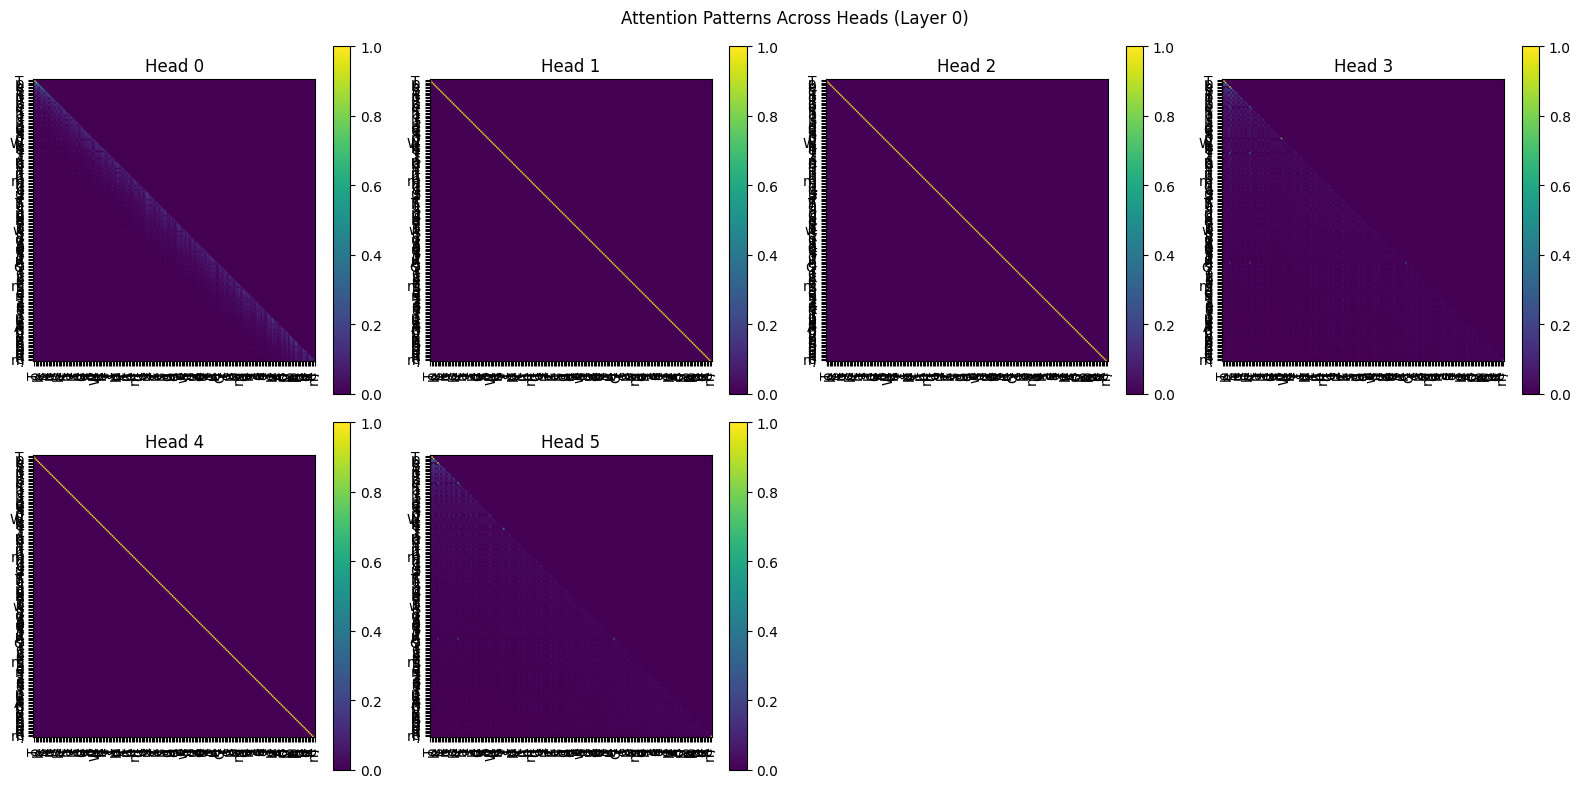

In [ ]:
def analyze_attention_heads(text, model, layer_idx=0):
    """Analyze attention patterns across all heads in a layer."""
    # Tokenize input
    chars = list(text)
    x = torch.tensor([ord(c) for c in chars], dtype=torch.long).unsqueeze(0)
    x = x.to(model.transformer.wte.weight.device)

    # Get attention weights using the custom function
    with torch.no_grad():
        logits, attention_weights = get_attention_patterns(model, x)

    n_heads = model.config.n_head
    n_cols = min(4, n_heads)
    n_rows = (n_heads + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(f"Attention Patterns Across Heads (Layer {layer_idx})")

    axes = axes.flatten() if n_heads > 1 else [axes]
    for i in range(n_heads):
        ax = axes[i]
        attn = attention_weights[layer_idx][0, i]
        im = ax.imshow(attn.cpu().numpy(), cmap="viridis")
        ax.set_xticks(range(len(chars)))
        ax.set_xticklabels(chars, rotation=90)
        ax.set_yticks(range(len(chars)))
        ax.set_yticklabels(chars)
        ax.set_title(f"Head {i}")
        plt.colorbar(im, ax=ax)
    # Hide any unused subplots
    for j in range(n_heads, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


print("Analyzing full text attention patterns...")
analyze_attention_heads(complex_text, model)